Importing OS to verify whether the files are uploaded

In [19]:
import os 
os.listdir()

['Advertising.csv',
 'mlops_sales.ipynb',
 '.DS_Store',
 'advertising-dataset.csv',
 '.ipynb_checkpoints']

# Importing dataset And Splitting The Dataset

In [20]:
import pandas as pd 
data = pd.read_csv("Advertising.csv")
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [21]:
X = data.drop("Sales",axis= 1)
y = data["Sales"]

In [22]:
split = int(len(data) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]    #This simulates:Past data → training;Future data → real-world

# Training a basic model

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Calculating MAE for deciding threshold 

In [24]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Initial MAE:", mae)

Initial MAE: 1.2648627117200737


In [33]:
from sklearn.metrics import mean_absolute_error

errors = []
threshold = 2   

for i in range(len(X_test)):
    X_batch = X_test.iloc[i:i+1]
    y_batch = y_test.iloc[i:i+1]

    pred = model.predict(X_batch)
    error = mean_absolute_error(y_batch, pred)

    errors.append(error)

    print(f"Step {i}, Error: {error}")

Step 0, Error: 1.5698406327819985
Step 1, Error: 0.9964846010705024
Step 2, Error: 0.9631252492764553
Step 3, Error: 1.841844626854657
Step 4, Error: 1.5176381504086471
Step 5, Error: 0.7390808767829995
Step 6, Error: 2.0046880722000893
Step 7, Error: 2.240194596620146
Step 8, Error: 1.2048873575268253
Step 9, Error: 0.4668192695124329
Step 10, Error: 2.1452228496894463
Step 11, Error: 1.8277963404103712
Step 12, Error: 0.35131672770116396
Step 13, Error: 0.9259183203498935
Step 14, Error: 0.2124614643378422
Step 15, Error: 1.8903179132311712
Step 16, Error: 0.13049824959034062
Step 17, Error: 0.28167528333003666
Step 18, Error: 2.8235044749060867
Step 19, Error: 0.7062352666259617
Step 20, Error: 0.36504965641921494
Step 21, Error: 0.021705744645226233
Step 22, Error: 0.1176596235681
Step 23, Error: 0.7660137941866338
Step 24, Error: 1.0022399286761878
Step 25, Error: 2.041555833599155
Step 26, Error: 2.5988664370845456
Step 27, Error: 0.9930300390178459
Step 28, Error: 0.130334090780

In [29]:
for i in range(len(X_test)):
    X_batch = X_test.iloc[i:i+1]
    y_batch = y_test.iloc[i:i+1]

    pred = model.predict(X_batch)
    error = mean_absolute_error(y_batch, pred)

    errors.append(error)

    print(f"Step {i}, Error: {error}")

    if error > threshold:
        print("⚠️ Retraining triggered...")

        # Add new data
        X_train = pd.concat([X_train, X_batch])
        y_train = pd.concat([y_train, y_batch])

        # Retrain model
        model.fit(X_train, y_train)

        print("✅ Model updated")
        

Step 0, Error: 1.469145479201707
Step 1, Error: 1.0060270523713513
Step 2, Error: 0.9226424568239224
Step 3, Error: 1.6082071636401505
Step 4, Error: 1.381509407900035
Step 5, Error: 0.4349758349139847
Step 6, Error: 2.3273824383807487
⚠️ Retraining triggered...
✅ Model updated
Step 7, Error: 2.4054619153021335
⚠️ Retraining triggered...
✅ Model updated
Step 8, Error: 1.090017373122885
Step 9, Error: 0.47123720552376547
Step 10, Error: 2.3943907088697998
⚠️ Retraining triggered...
✅ Model updated
Step 11, Error: 1.7512438396292485
Step 12, Error: 0.32091357087610817
Step 13, Error: 1.0087180150821524
Step 14, Error: 0.17185652862132272
Step 15, Error: 1.917022253523732
Step 16, Error: 0.2696923881050921
Step 17, Error: 0.14600897526867307
Step 18, Error: 2.692622483533076
⚠️ Retraining triggered...
✅ Model updated
Step 19, Error: 0.7765602936873695
Step 20, Error: 0.40326095535312234
Step 21, Error: 0.20866651181388107
Step 22, Error: 0.14337395378124995
Step 23, Error: 0.9216821787878

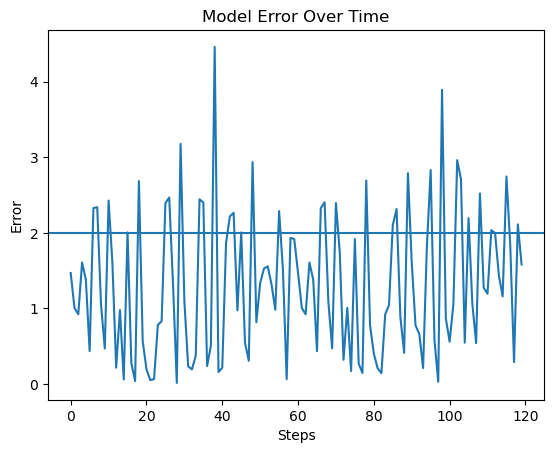

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(errors)
plt.axhline(y=threshold)
plt.title("Model Error Over Time")
plt.xlabel("Steps")
plt.ylabel("Error")
plt.show()

In [34]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']